In [ ]:
import os
import sys
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
sys.path.append(os.path.abspath("../data"))
from models.gcn_model import GCN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
def load_graph(path):
    return torch.load(path, weights_only=False).to(device)


def evaluate(model, graph):
    model.eval()
    with torch.no_grad():
        out = model(graph.x, graph.edge_index)
        preds = out.argmax(dim=1).cpu()
        labels = graph.y.cpu()
    return accuracy_score(labels, preds)

In [ ]:
def apply_ldp(model, epsilon, alpha=0.3):
    """
    epsilon: privacy budget (lower = stronger privacy)
    alpha: noise strength
    """
    noisy_model = copy.deepcopy(model)

    for _, param in noisy_model.named_parameters():
        if not param.requires_grad:
            continue

        noise_std = alpha / epsilon
        noise = torch.normal(
            mean=0.0,
            std=noise_std,
            size=param.data.size()
        ).to(device)

        param.data += noise

    return noisy_model

In [ ]:
def select_best_epsilon(clean_model, graph, epsilons, alpha=0.8):
    clean_acc = evaluate(clean_model, graph)
    print(f"\nClean Accuracy: {clean_acc:.4f}")

    best_score = -float("inf")
    best_eps = None
    best_model = None
    noisy_accuracies = []

    eps_max = max(epsilons)

    for eps in epsilons:
        noisy_model = apply_ldp(clean_model, eps)
        noisy_acc = evaluate(noisy_model, graph)

        # Privacy–Utility tradeoff score
        score = alpha * noisy_acc - (1 - alpha) * (eps / eps_max)

        noisy_accuracies.append(noisy_acc)

        print(
            f"ε={eps} | Noisy Acc={noisy_acc:.4f} | "
            f"Score={score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_eps = eps
            best_model = noisy_model

    print(f"Selected ε={best_eps} (Best Score={best_score:.4f})")

    return best_model, best_eps, noisy_accuracies, clean_acc


In [ ]:
if __name__ == "__main__":

    epsilons = [1.5, 2, 3, 4, 5]

    # Load graphs
    graph_A = load_graph("../data/graph/graph_A.pt")
    graph_B = load_graph("../data/graph/graph_B.pt")
    graph_C = load_graph("../data/graph/graph_C.pt")

    input_dim = graph_A.num_node_features

    # Initialize models
    model_A = GCN(input_dim, 32, 2).to(device)
    model_B = GCN(input_dim, 32, 2).to(device)
    model_C = GCN(input_dim, 32, 2).to(device)

    # Load trained local models
    model_A.load_state_dict(torch.load("../data/models/model_A.pth"))
    model_B.load_state_dict(torch.load("../data/models/model_B.pth"))
    model_C.load_state_dict(torch.load("../data/models/model_C.pth"))

    # LDP ε selection
    model_A_ldp, eps_A, accs_A, clean_A = select_best_epsilon(model_A, graph_A, epsilons)
    model_B_ldp, eps_B, accs_B, clean_B = select_best_epsilon(model_B, graph_B, epsilons)
    model_C_ldp, eps_C, accs_C, clean_C = select_best_epsilon(model_C, graph_C, epsilons)

    # Save selected models
    os.makedirs("../data/models", exist_ok=True)

    torch.save(model_A_ldp.state_dict(), "../data/models/model_A_ldp.pth")
    torch.save(model_B_ldp.state_dict(), "../data/models/model_B_ldp.pth")
    torch.save(model_C_ldp.state_dict(), "../data/models/model_C_ldp.pth")

    print("\nBest LDP models sent to global server")


Clean Accuracy: 0.9875
ε=1.5 | Noisy Acc=0.9812 | Gap=0.0063
ε=2 | Noisy Acc=0.9844 | Gap=0.0031
ε=3 | Noisy Acc=0.9781 | Gap=0.0094
ε=4 | Noisy Acc=0.9812 | Gap=0.0063
ε=5 | Noisy Acc=0.9875 | Gap=0.0000
Selected ε=5 (Gap=0.0000)

Clean Accuracy: 0.9830
ε=1.5 | Noisy Acc=0.9545 | Gap=0.0284
ε=2 | Noisy Acc=0.9830 | Gap=0.0000
ε=3 | Noisy Acc=0.9773 | Gap=0.0057
ε=4 | Noisy Acc=0.9830 | Gap=0.0000
ε=5 | Noisy Acc=0.9830 | Gap=0.0000
Selected ε=2 (Gap=0.0000)

Clean Accuracy: 1.0000
ε=1.5 | Noisy Acc=1.0000 | Gap=0.0000
ε=2 | Noisy Acc=1.0000 | Gap=0.0000
ε=3 | Noisy Acc=1.0000 | Gap=0.0000
ε=4 | Noisy Acc=1.0000 | Gap=0.0000
ε=5 | Noisy Acc=1.0000 | Gap=0.0000
Selected ε=1.5 (Gap=0.0000)

Best LDP models sent to global server


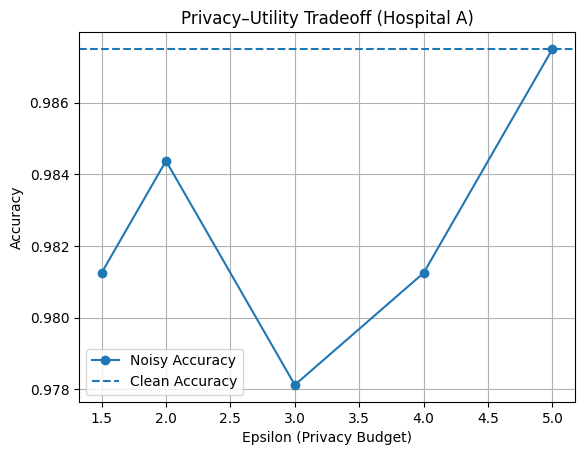

In [ ]:
plt.figure()
plt.plot(epsilons, accs_A, marker="o", label="Noisy Accuracy")
plt.axhline(y=clean_A, linestyle="--", label="Clean Accuracy")
plt.xlabel("Epsilon (Privacy Budget)")
plt.ylabel("Accuracy")
plt.title("Privacy–Utility Tradeoff (Hospital A)")
plt.legend()
plt.grid(True)
plt.show()